---
### **<p style="text-align: center; text-decoration: underline;">Introduction to GCNs</p>**
# **<p style="text-align: center;">Graph Convolutional Networks (GCNs) for ENZYMES Recognition</p>**
---

> Realized by: *Omar Ikne*.

> Degree: Master, IMT Nord Europe

---

### ■ __Overview__
In this notebook, we will investigate the utilization of Graph Convolutional Networks (GCNs) for enzymes recognition. Specifically, we aim to classify different enzymes using graph representations. The fundamental concept involves using the capabilities of GCNs to extract insightful features from different enzymes and subsequently classify each gesture individually.

The main task of this lab is to build a graph-based deep learning model to recognize the enzymes (figure bellow).
#### **Main Task: Enzymes Recognition**
![Alt text](https://imgs.search.brave.com/4EK1Y4pTpVRybeHANa7UmRMPI_FEOmnAt_uPo8edhpQ/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9pbWcu/bWFnbmlmaWMuY29t/L3ByZW1pdW0tcGhv/dG8vdmlicmFudC1p/bGx1c3RyYXRpb24t/ZW56eW1lLWNhdGFs/eXNpcy1oaWdobGln/aHRpbmctZHluYW1p/Yy1iaW9jaGVtaWNh/bC1yZWFjdGlvbnMt/Y29uY2VwdC1iaW9j/aGVtaWNhbC1pbGx1/c3RyYXRpb24tZW56/eW1lLWNhdGFseXNp/cy1keW5hbWljLXJl/YWN0aW9ucy12aWJy/YW50LWNvbG9ycy1i/aW9sb2dpY2FsLXBy/b2Nlc3Nlc184NjQ1/ODgtMTc1MzY2Lmpw/Zz9zZW10PWFpc19o/eWJyaWQmdz03NDAm/cT04MA)

### ■ **<a name="content">Contents</a>**

- [1. Preliminaries](#section1)

- [1. Enzymes Dataset](#section2)

- [2. GCN Model](#section3)

- [3. Model Training](#section4)

- [4. Model Evaluation](#section5)

- [5. Demo](#section6)


### ■ **Libraries**

In [1]:
!pip install torch
!pip install torch_geometric
!pip install networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 746.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.7 MB/s eta 0:00:00


In [2]:
## torch dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as transforms
import torch.optim as optim

## basic dependencies from math and visualization
import networkx as nx
import numpy as np
import random
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from copy import deepcopy
import time

In [3]:
## Fix a seed to control randomness and make results reproducible!
def seed_everything(seed=51):
    """seeds every package that might introduce randomness."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(0)

### ■ **<a name="pre">1. Preliminaries</a>** [(&#8593;)](#content)
The ENZYMES dataset is commonly used as a benchmark dataset in the field of graph classification, particularly for evaluating the performance of graph-based machine learning models, including Graph Convolutional Networks (GCNs).
ENZYMES is a dataset of protein tertiary structures obtained from (Borgwardt et al., 2005) consisting of 600 enzymes from the BRENDA enzyme database (Schomburg et al., 2004). In this case the task is to correctly assign each enzyme to one of the 6 EC top-level classes.
Below is a general description of the ENZYMES dataset:

#### `ENZYMES Dataset:`

1. **Source:**
   - The ENZYMES dataset is often used in the context of graph classification tasks.
   - It is part of the TU Dortmund University Graph Database ([TUDataset](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.TUDataset.html#torch_geometric.datasets.TUDataset)).

2. **Graphs:**
   - Each graph in the dataset represents the 3D structure of a protein.
   - Nodes in the graph represent amino acids, and edges represent interactions between amino acids.

3. **Labels:**
   - The dataset is typically used for graph classification, where each graph is associated with a class label.
   - Class labels represent different enzyme classes or families.

4. **Tasks:**
   - The primary task associated with the ENZYMES dataset is graph classification.
   - The goal is to train a model to predict the enzyme class or family based on the graph representation of the protein's 3D structure.

5. **Graph Properties:**
   - The graphs are heterogeneous and vary in terms of the number of nodes and edges.
   - Each graph captures the structural information of a different protein, making it suitable for evaluating models' ability to generalize to diverse graph structures.

6. **Dataset Size:**
   - The ENZYMES dataset typically consists of a moderate number of graphs, with each graph corresponding to a unique protein structure.

7. **Use in Research:**
   - Researchers often use the ENZYMES dataset to assess the performance of graph-based machine learning models, especially graph classification algorithms like GCNs.

8. **Availability:**
   - The ENZYMES dataset is publicly available and can be accessed through graph database [TUDataset](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.TUDataset.html#torch_geometric.datasets.TUDataset).


![Alt text](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fimage3.slideserve.com%2F6898777%2Fenzyme-and-protein-structure-l.jpg&f=1&nofb=1&ipt=81702931cf27e65b54827ac537d59f70610c91ecc48d8b8172cff0664ee9e345&ipo=images "Enzyme Structure")

#### **Dataset Overview**

Let's start by uploading the dataset and see some statistics and examples !

In [4]:
## load ENZYMES dataset
dataset = TUDataset('./', 'ENZYMES')

## print information
print(dataset)
print('------------')
print(f'Number of graphs  : {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes : {dataset.num_classes}')

Processing...


ENZYMES(600)
------------
Number of graphs  : 600
Number of features: 3
Number of classes : 6


Done!


/usr/local/lib/python3.13/dist-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  node_collection = ax.scatter(


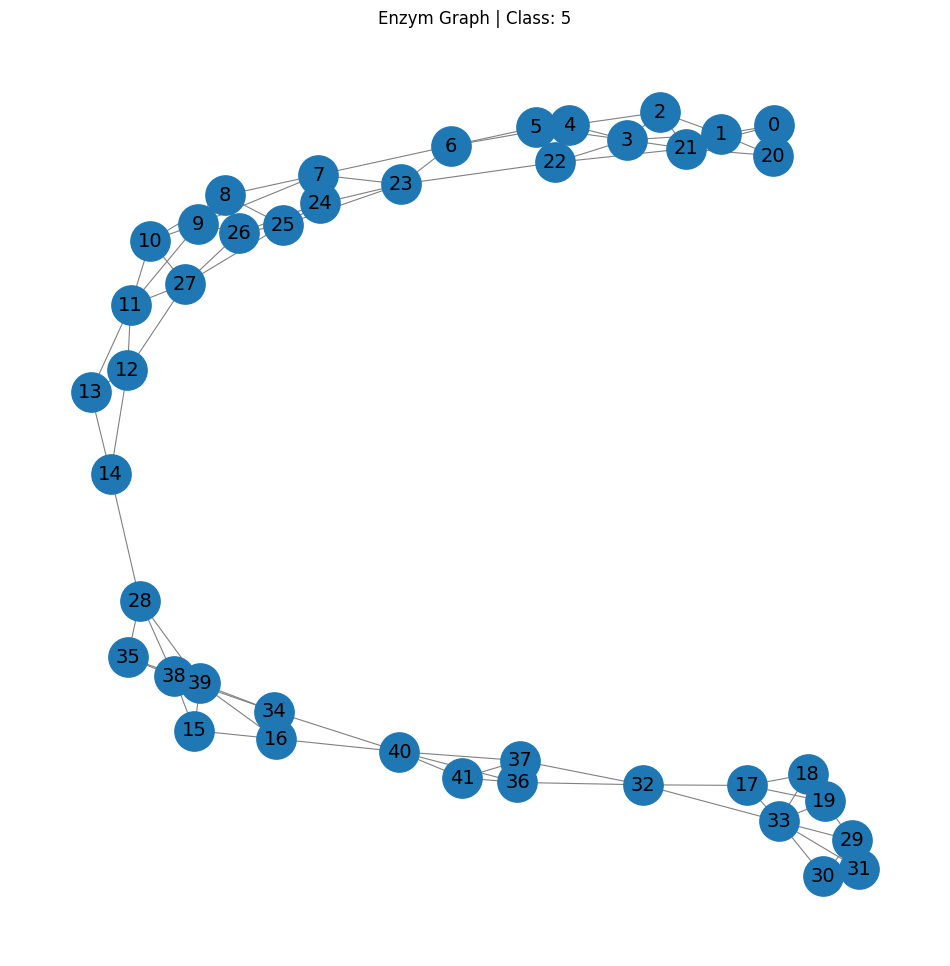

In [5]:
from torch_geometric.utils import to_networkx

def draw_graph(data):
    ## convert data to networkX graph
    G = to_networkx(data, to_undirected=True)
    ## create a new plt figure
    plt.figure(figsize=(12,12))
    ## turn off axis display
    plt.axis('off')
    ## draw graph
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=True,
                    node_size=800,
                    node_color=data.batch,
                    cmap="hsv",
                    vmin=-2,
                    vmax=3,
                    width=0.8,
                    edge_color="grey",
                    font_size=14
                    )
    plt.title('Enzym Graph | Class: {}'.format(data.y.item()))
    plt.show()

## display an example
data = dataset[20].detach()
draw_graph(data)

### ■ **<a name="dataset">2. Dataset</a>** [(&#8593;)](#content)
In this second section, our focus shifts to creating the dataset essential for training the Graph Convolutional Network (GCN). The dataset is designed to provide different enzymes, the corresponding adjacency matrices (here encoded by an edge indices map), and the associated sign labels.

#### **2.2 Define the dataset**

In [6]:
class EnzymesDataModule(nn.Module):
    def __init__(
        self,
        data_dir="/data/",
        batch_size=64,
        num_workers=0,
        splits=[0.7, 0.15, 0.15],
        seed=51,
    ):
        super(EnzymesDataModule, self).__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.splits = splits
        self.seed = seed
        self.transform = transforms.Compose(
            [
                transforms.NormalizeFeatures(),
            ]
        )

        ## Number of graphs, classes and features
        self.num_graphs = 600
        self.num_classes = 6
        self.num_features = 21

        ## prepare and setup data
        self.setup()

    def setup(self, stage=None):
        initial_seed = torch.initial_seed()
        torch.manual_seed(self.seed)
        dataset = TUDataset(
            root=self.data_dir,
            name="ENZYMES",
            use_node_attr=True,
            use_edge_attr=True,
            pre_transform=self.transform,
        ).shuffle()

        ## print information
        print(dataset)
        print('------------')
        print(f'Number of graphs  : {len(dataset)}')
        print(f'Number of features: {dataset.num_features}')
        print(f'Number of classes : {dataset.num_classes}')

        ## split dataset
        split_idx = np.cumsum(
            [int(len(dataset) * prop) for prop in self.splits])
        self.data_train = dataset[: split_idx[0]]
        self.data_val = dataset[split_idx[0]: split_idx[1]]
        self.data_test = dataset[split_idx[1]:]
        torch.manual_seed(initial_seed)

    def train_dataloader(self):
        return DataLoader(
            self.data_train,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            shuffle=True,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.data_val,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            shuffle=False,
            pin_memory=True,
        )

    def eval_dataloader(self):
        return DataLoader(
            self.data_val,
            batch_size=1,
            num_workers=self.num_workers,
            shuffle=True,
            pin_memory=True,
        )

In [7]:
## define a batch size
batch_size = 16

## create the enzymes dataset
dm = EnzymesDataModule(data_dir="./",
                       batch_size=batch_size,
                       splits=[0.8, 0.2])


## get the trainig and validation data laoder
train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

## print some stats
print('The number of training batches   :', len(train_loader))
print('The number of validation batches :', len(val_loader))

ENZYMES(600)
------------
Number of graphs  : 600
Number of features: 21
Number of classes : 6
The number of training batches   : 30
The number of validation batches : 8


/usr/local/lib/python3.13/dist-packages/torch_geometric/data/dataset.py:116: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


In [8]:
## check that the loaders work well by extracting an element from the laoder.
## out is a dictionary that contains a batch data from the loader.
## out contains: edge_index -> shape(2, x), x -> shape (number of nodes, number of features), batch -> shape (number of nodes), y -> shape (batch_size)
out = next(iter(train_loader))
out

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DataBatch(edge_index=[2, 1838], x=[558, 21], y=[16], batch=[558], ptr=[17])

In [9]:
out.batch[455]

tensor(12)

In [16]:
out.edge_index

tensor([[  0,   1,   1,  ..., 557, 557, 557],
        [  6,  30,  31,  ..., 549, 555, 556]])

In [17]:
out.edge_index.shape

torch.Size([2, 1838])

In [18]:
out.y

tensor([2, 4, 1, 5, 3, 2, 0, 5, 4, 2, 1, 4, 5, 1, 2, 3])

In [19]:
out.batch

tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
         3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
         3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
         5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  6,  6, 

In [11]:
mat_adj = np.zeros((2222, 2222))
mat_adj[out.edge_index[0], out.edge_index[1]] = 1
mat_adj

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
out.batch[0]

tensor(0)

#### **> `Question 1:`**
- Describe each component of the data loader output and what the shape of each corresponds to.
    - edge index,
    - x,
    - y,
    - batch,
    - ptr,

#### > **Your Answer:**

* **edge_index**: represents connectivity (the edges) as a tensor. Its shape `[2, 1838]` holds the source node indices on the first row and the target node indices on the second row, for all edges accumulated in the batch.

* **x**: the node feature matrix. Its shape `[558, 21]` corresponds to the total number of nodes accumulated in the batch ($N = 558$) times the number of features per node ($F = 21$).

* **y**: the class labels associated with each individual graph. Its shape `[16]` corresponds to the batch size (`batch_size = 16`).

* **batch**: a mapping vector that assigns each node to its graph within the batch. Its shape `[558]` maps each of the 558 nodes to a graph index between 0 and 15.

* **ptr**: a slicing pointer giving the start and end node indices of each individual graph in the merged batch. Its shape is `[17]`.

Here we do some data analysis by ploting the number of samples per class. This allows us to see whether the data is balanced or not !

/tmp/ipykernel_7426/669042954.py:2: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  values, counts = np.unique(dataset.data.y.numpy(), return_counts=True)


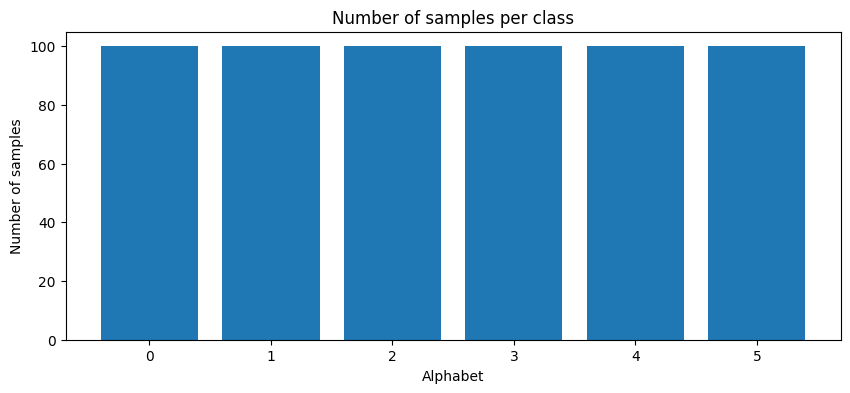

In [20]:
## plot the number of samples per class
values, counts = np.unique(dataset.data.y.numpy(), return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar(values, counts)
plt.title('Number of samples per class')
plt.xlabel('Alphabet')
plt.ylabel('Number of samples')
plt.show()

#### **> `Question 2:`**
- What do you observe?

#### > **Your Answer:**

The dataset is perfectly balanced: 6 classes with 100 graphs each. Accuracy is therefore a meaningful metric, chance level is $1/6 \approx 16.7\%$, and no class weighting or resampling is needed.

#### **Adjacency Matrix**

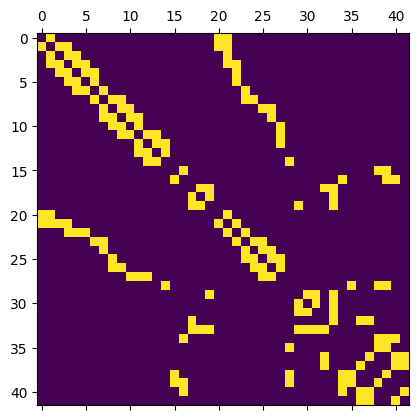

In [21]:
from torch_geometric.utils import to_dense_adj

## converts edge mapping into adjacency matrix
adjacency_matrix = to_dense_adj(data.edge_index)[0]
## show
plt.matshow(adjacency_matrix)
plt.show()

In [22]:
out.x.shape

torch.Size([558, 21])

In [23]:
out.ptr

tensor([  0,  48,  64, 115, 148, 186, 212, 231, 267, 291, 324, 352, 360, 460,
        487, 517, 558])

In [24]:
out.batch

tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
         3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
         3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
         5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  6,  6, 

In [25]:
data.edge_index

tensor([[ 0,  0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,
          4,  4,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,  7,  7,  7,
          8,  8,  8,  8,  8,  9,  9,  9,  9,  9, 10, 10, 10, 10, 11, 11, 11, 11,
         11, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15, 15, 16, 16, 16, 16,
         17, 17, 17, 17, 18, 18, 18, 19, 19, 19, 19, 20, 20, 20, 21, 21, 21, 21,
         21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 24, 25, 25,
         25, 25, 25, 26, 26, 26, 26, 26, 27, 27, 27, 27, 27, 28, 28, 28, 28, 29,
         29, 29, 29, 30, 30, 30, 31, 31, 31, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 34, 34, 34, 34, 35, 35, 35, 36, 36, 36, 36, 37, 37, 37, 37, 38,
         38, 38, 38, 38, 39, 39, 39, 39, 39, 39, 40, 40, 40, 40, 40, 41, 41, 41],
        [ 1, 20, 21,  0,  2,  3, 20, 21,  1,  3,  4, 21,  1,  2,  4,  5, 21, 22,
          2,  3,  5,  6, 22,  3,  4,  6, 22,  4,  5,  7, 23,  6,  8,  9, 23, 24,
          7,  9, 10, 25, 26

### **Distribution of the number of nodes in enzymes in the dataset**

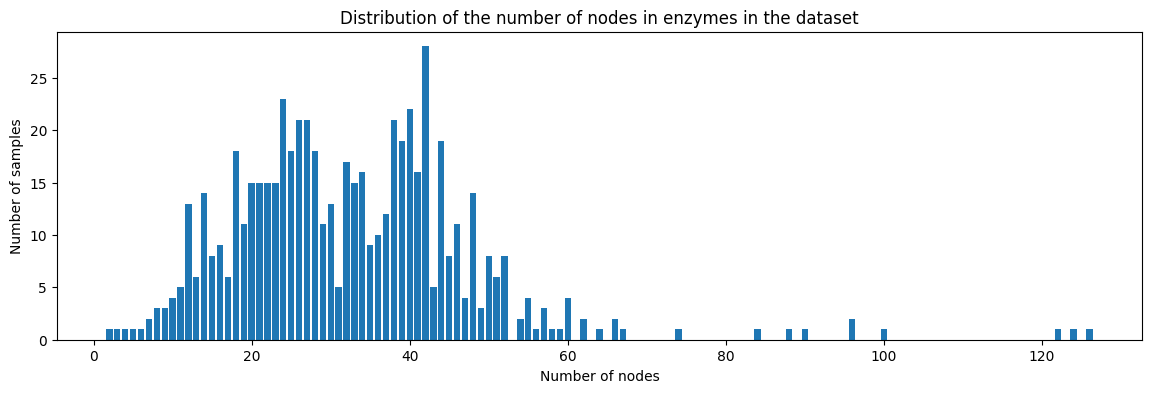

In [26]:
## plot the number of nodes in enzymes in the dataset
plt.figure(figsize=(14, 4))
plt.bar(*np.unique([d.num_nodes for d in dataset], return_counts=True))
plt.xlabel('Number of nodes')
plt.ylabel('Number of samples')
plt.title('Distribution of the number of nodes in enzymes in the dataset')
plt.show()

#### **> `Question 3:`**
- What do you observe?

#### > **Your Answer:**

Graph sizes vary a lot. Most enzymes have between about 10 and 55 nodes, with the bulk between 20 and 45 (mean ≈ 33). The distribution is not a clean bell curve: it has two bumps (around 25 and around 40 nodes) and a long right tail of rare, much larger graphs (up to about 125 nodes).

Variable sizes are not a problem for a GCN: the same weights are shared by every node, and global pooling turns any graph into a fixed-size vector. With mean pooling, the graph representation does not depend on the number of nodes; with sum pooling, larger graphs would produce larger activations.

### ■ **<a name="model">3. GCN Model</a>** [(&#8593;)](#content)
No that the dataloaders are ready, we can build our GCN model to classify enzymes ! We define the GCN model by stacking a set of GCN layers to extract features, and an MLP layer to classify the extracted features into different classes.

![Alt text](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fgowrishankar.info%2Fblog%2Fgraph-convolution-network-a-practical-implementation-of-vertex-classifier-and-its-mathematical-basis%2Fgcn.png&f=1&nofb=1&ipt=dc6110ac79639d176fda8c6a9e42d2d89e1ded4a06f06730903cb048e1a2b0b3&ipo=images "GCN architecture")

#### **> `Question 4:`**
- Complete the following GCN module class by adding the appropriate shapes to the GCN layers, and the fully connected (Linear) input and output shapes.

- Perform message passing through GCN layers in the forward function by writing the correct code as seen in the course !

> **Notes:**
> - Replace the dots '...' with your answer !
> - In the figure above, replace the pooling layer with the activation function.

In [29]:
from torch_geometric.nn import (GCNConv, global_add_pool, global_max_pool, global_mean_pool)

class GCN(nn.Module):
    """
    Graph Convolutional Network (GCN) model.

    Parameters:
    - n_node_features (int): Number of input node features.
    - n_classes (int): Number of output classes.
    - conv_channels (int): Number of channels in the graph convolutional layers.
    - fc_size (int): Size of the fully connected layer.
    - global_pooling (function): Global pooling function for aggregating node features.
    - activation (nn.Module): Activation function to apply after graph convolutional layers.
    - dropout (float): Dropout ratio.
    """

    def __init__(
        self,
        n_node_features: int,
        n_classes: int,
        conv_channels: int = 32,
        fc_size: int = 32,
        global_pooling = global_mean_pool,
        activation = nn.LeakyReLU,
        dropout: float = 0.15,
    ):
        super(GCN, self).__init__()
        self.n_node_features = n_node_features
        self.n_classes = n_classes
        self.conv_channels = conv_channels
        self.fc_size = fc_size
        self.activation = activation()
        self.dropout_rate = dropout

        ## TO DO ! add the appropriate shapes
        ## Graph Convolutional Layers
        self.gcn1 = GCNConv(in_channels=n_node_features, out_channels=conv_channels)
        self.gcn2 = GCNConv(in_channels=conv_channels, out_channels=conv_channels)

        ## Fully Connected Layers
        self.fc1 = nn.Linear(in_features=conv_channels, out_features=fc_size)
        self.fc2 = nn.Linear(in_features=fc_size, out_features=n_classes)

        ## Global Pooling and Dropout
        self.global_pooling = global_pooling
        self.dropout = nn.Dropout(p=self.dropout_rate)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor):
        ## Check input dimensions
        if x.shape[1] != self.n_node_features:
            raise ValueError(
                f"Number of node features of input x is correct. "
                f"Expected {self.n_node_features} but got {x.shape[1]}."
            )
        if batch.shape[0] != x.shape[0]:
            raise ValueError(
                "Number of nodes in x is incompatible with the number of nodes "
                "in batch."
            )

        ## TO DO !
        ## Perform message passing
        x = self.gcn1(x, edge_index)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.gcn2(x, edge_index)
        x = self.activation(x)
        x = self.dropout(x)

        ## Apply global pooling layer
        embed = self.global_pooling(x, batch)  # [batch_size, conv_channels]

        ## Feed through linear layer for prediction
        embed = self.fc1(embed)
        embed = self.activation(embed)
        embed = self.dropout(embed)
        out = self.fc2(embed)  # [batch_size, n_classes]

        return out

### ■ **<a name="train">4. Model Training</a>** [(&#8593;)](#content)
We are now ready to train our model. We define a `train_epoch` function to train our model for one epoch.

In [30]:
def train_epoch(model, optimizer, dataloader, device, criterion, scheduler=None):
    """
    to train the model for one epoch !
    Params:
    ======
        - model: model to train,
        - optimizer: optimizer to optimize the loss of the model,
        - dataloader: the training data laoder.
        - device: cpu or gpu,
        - criterion: the loss function,
        - sheduler[defualt=None]: if any to adjust the learning rate of the optimizer.
    """

    ## make the model in train mode
    model.train()

    ## create a progression bar to display the progression of training
    pbar = tqdm(dataloader, total=len(dataloader))
    total_loss = 0

    ## for each batch
    for batch in pbar:
        ## get data from the batch
        batch = batch.to(device) # contains (batch.x, batch.edge_index, batch.batch, batch.y)

        ## predict and calculate the loss on the given batch, and optimize the loss accordingly
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss_train = criterion(pred, batch.y.flatten())
        loss_train.backward()
        optimizer.step()

        total_loss += loss_train.item()
        ## set the discription bar
        pbar.set_description('[TRAIN]> loss. %.3f' % (total_loss/len(batch.y)))

    if scheduler is not None:
        scheduler.step()

    return total_loss


def validate_epoch(model, dataloader, criterion):
    """to evaluate the model !
    Params:
    ======
        - model: model to evaluate,
        - dataloader: the validation data laoder.
        - criterion: the loss function to calculate the validation loss,
    """

    acc = 0.0
    n = 0
    pred_labels, true_labels = [], []
    total_loss = 0.0

    ## turn the model into evaluation mode
    model.eval()

    ## no need to compute grads in validation stage, this makes the process run fast
    with torch.no_grad():
        pbar = tqdm(dataloader, total=len(dataloader))

        for batch in pbar:
            batch = batch.to(device) # contains (batch.x, batch.edge_index, batch.batch, batch.y)

            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y.flatten())

            ## calculate accuracy
            acc += (pred.argmax(dim=1) == batch.y.flatten()).sum().item()
            n += len(batch.y.flatten())

            total_loss += loss.item()

            ## append true and predcted labels to storage
            true_labels.extend(batch.y.tolist())
            pred_labels.extend(pred.argmax(dim=1).tolist())

            ## update progress bar
            desc = '[VALID]> acc. %.2f%%' % ((acc / n)*100)
            pbar.set_description(desc)

    ## normalize accuracy
    accuracy = acc / n

    return total_loss, accuracy, true_labels, pred_labels

#### **> `Question 5:`**
- Complete the code bellow with the appropriate parameters to train the model.

In [31]:
## model parameters
n_node_features = 21
conv_channels = 64
n_classes = 6
fc_size = 64
dropout = 0.15

activation = nn.LeakyReLU # in [nn.ReLU, nn.LeakyReLU, nn.GELU, etc]
global_pooling = global_mean_pool # in [global_mean_pool, global_add_pool, global_max_pool]

## device: cpu / gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('available device:', device)

## build model
model = GCN(n_node_features=n_node_features,
            n_classes=n_classes,
            conv_channels=conv_channels,
            fc_size=fc_size,
            global_pooling=global_pooling,
            activation=activation,
            dropout=dropout).to(device)

## trainig parameters
lr = 1e-3 # learning rate
weight_decay = 5e-4
num_epochs = 150 # number of training epochs

## create optimizer, schedular and loss function
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
scheduler = None # optionnal

# Training loop
valid_accuracies = []
valid_losses = []

best_preds = None
best_acc = 0.0
best_model = model

## chrono
start_time = time.time()

for epoch in range(1, num_epochs+1):

    print('EPOCH %.3g/%.3g:' % (epoch, num_epochs))

    ## train epoch
    train_loss = train_epoch(model, optimizer, train_loader, device, criterion)
    ## validation epoch
    valid_loss, val_acc, true_labels, pred_labels = validate_epoch(model, val_loader, criterion)

    valid_accuracies.append(val_acc * 100)
    valid_losses.append(valid_loss)

    ## keep best accuracy and model
    if best_acc < val_acc:
        best_preds = pred_labels
        best_acc = val_acc
        best_model = deepcopy(model)

## stop chrono
train_time = time.time() - start_time
print('\n> Training took {} [min:sec]'.format(time.strftime("%M:%S", time.gmtime(train_time))))

available device: cpu
EPOCH 1/150:


  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[VALID]> acc. 17.50%: 100%|██████████| 8/8 [00:00<00:00, 162.82it/s]


EPOCH 2/150:


[VALID]> acc. 17.50%: 100%|██████████| 8/8 [00:00<00:00, 187.84it/s]


EPOCH 3/150:


...

EPOCH 149/150:


[VALID]> acc. 44.17%: 100%|██████████| 8/8 [00:00<00:00, 188.99it/s]


EPOCH 150/150:


[VALID]> acc. 40.83%: 100%|██████████| 8/8 [00:00<00:00, 156.83it/s]


> Training took 00:54 [min:sec]


### ■ **<a name="eval">4. Model Evaluation</a>** [(&#8593;)](#content)
Now we evaluate our trained model. We plot both the validation loss and accuracy. We also plot the confusion matrix for different classes.

#### **4.1. Loss and accuracy**

The best validation accuracy: 49.17%


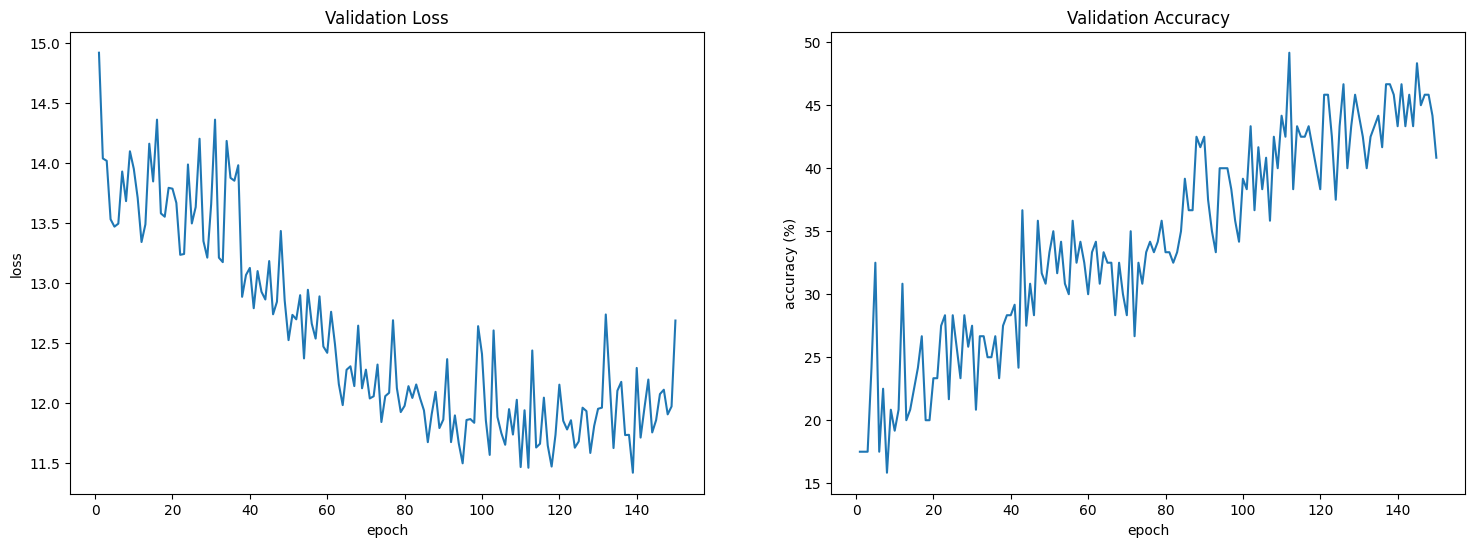

In [32]:
print(f'The best validation accuracy: {round(best_acc * 100, 2)}%')

## display validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

## loss
ax1.plot(range(1, num_epochs+1), valid_losses)
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.set_title('Validation Loss')

## accuracy
ax2.plot(range(1, num_epochs+1), valid_accuracies)
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy (%)')
ax2.set_title('Validation Accuracy')

plt.show()

#### **> `Question 6:`**
- What are your toughts about these results ?

#### > **Your Answer:**

The best validation accuracy is **49.2 %**, about three times chance level (16.7 %): the GCN learns useful structure, but ENZYMES remains a hard benchmark (simple GNNs typically reach roughly 50 to 65 %).

- The validation loss decreases until about epoch 100, then plateaus while oscillating; the accuracy is still slowly rising at epoch 150, so a longer training or a learning-rate schedule could still help a little.
- The curves are very noisy because the validation set is small (120 graphs, so one graph is worth about 0.8 point).
- The reported 49.2 % is the **best** epoch selected on this same validation set, so it is an optimistic estimate. A separate test set, or the 10-fold cross-validation usually used on ENZYMES, would give a fairer number.
- Possible improvements: a more expressive layer (GIN, GraphSAGE), sum or attention pooling, more layers with residual connections, and a learning-rate scheduler.

#### **4.2. Confusion Matrix**

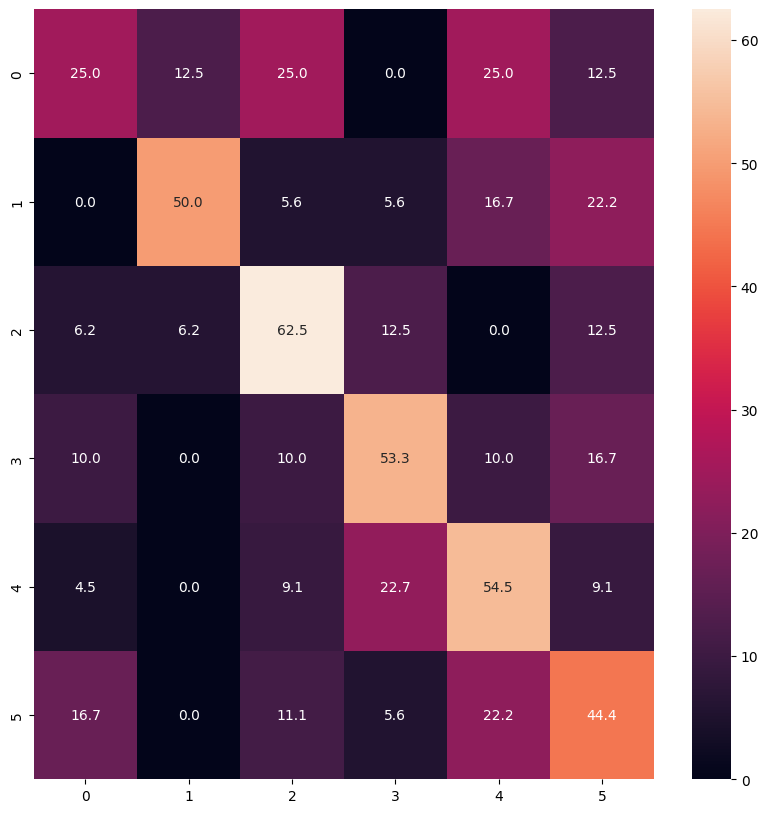

In [33]:
from sklearn.metrics import confusion_matrix

## calculate the confusion matrix
cm = confusion_matrix(true_labels, best_preds, normalize='true') # normalize to get percent values

## display
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(cm * 100, ax=ax, annot=True, fmt='.1f') # *100 to convert to percent % values
plt.show()

#### **> `Question 7:`**
- What are your toughts about these results ?

#### > **Your Answer:**

The diagonal dominates for every class, so each enzyme class is recognized above chance, but per-class recall varies a lot: class 2 is the best recognized (62.5 %), classes 1, 3 and 4 are around 50 to 55 %, class 5 reaches 44 %, and class 0 is the weakest (25 %).

The errors are spread over several classes rather than concentrated on one pair (the largest confusions are 4 → 3 at 22.7 % and 1 → 5 / 5 → 4 at about 22 %). This suggests that the model lacks discriminative features overall, rather than mixing up two specific, similar classes. These per-class values are also noisy: with about 20 validation graphs per class (only 8 for class 0), one graph changes a cell by 5 to 12 points.

### ■ **<a name="demo">4. Demo</a>** [(&#8593;)](#content)
Now yu can test your trained model on any given  enzym data :)

In [34]:
def plot_prediction_probability(probas):
    """plots the prediction confidence across classes !"""
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(n_classes)

    ax.bar(x, probas, width=0.2, color='b', align='center', alpha=0.8)
    ax.set_xlabel('Class')
    ax.set_ylabel('Probability')
    ax.set_title('Prediction Probability Distribution')
    plt.show()

def enzym_recognition_demo(model, enzym_data):
    """Predicts the enzym class given an enzym data, and a trained model !"""

    ## display enzym
    draw_graph(enzym_data)

    ## put model in mode evaluation
    model.eval()

    ## predict
    enzym_data = enzym_data.to(device)
    pred = model(enzym_data.x, enzym_data.edge_index, enzym_data.batch)
    probas = F.softmax(pred, dim=1)
    pred_labels = probas.argmax(dim=1)

    ## print results
    print('\t> True label     :', enzym_data.y.item())
    print('\t> Predicted label:', pred_labels.item(), '| Probability:', round(probas[0].max().item(), 2))

    ## plot prediction probability
    plot_prediction_probability(probas[0].detach().numpy())

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


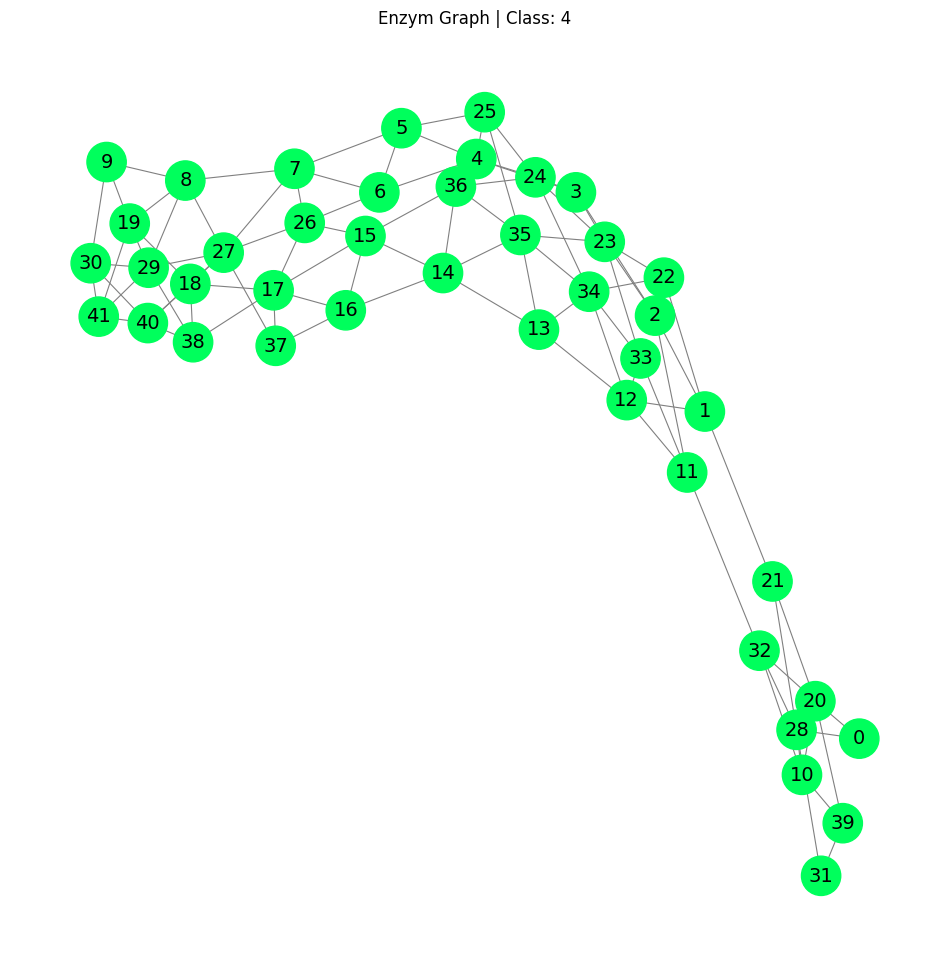

	> True label     : 4
	> Predicted label: 3 | Probability: 0.36


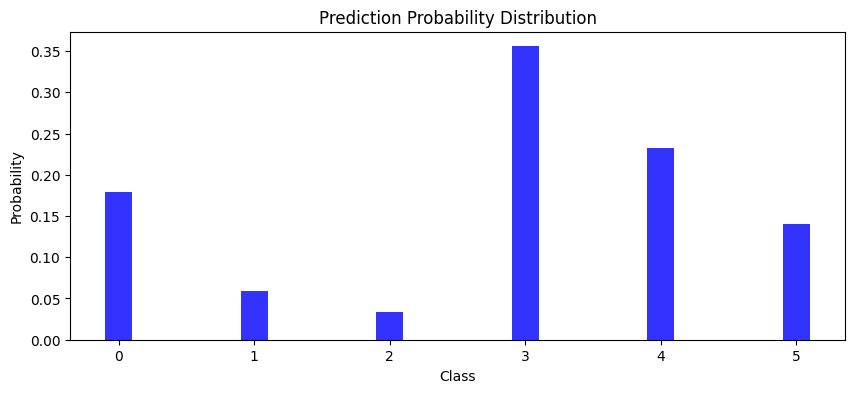

In [35]:
## get evaluation loader
eval_loader = dm.eval_dataloader()

## pick an enzym
enzym_data = next(iter(eval_loader))

## get the prediction
enzym_recognition_demo(model, enzym_data)

### ■ **<a name="impact">6. Impact of different parameters on the model</a>** [(&#8593;)](#content)

The following questions aim to expolre the impact of different parameters on the performance of the model. For each of these questions, plot the accuracy with respects to the parameter, plot the confusion matrices and make some comments.



#### **> `Question 8:`**
- Train the same model with different aggregation function (global_add_pool global_max_pool, global_mean_pool) and comment your findings !

#### **> `Question 9:`**
- Train the same model with different `conv_channels` values (64, 128, 256, ...) and describe what you notice.

#### **> `Question 10:`**
- Train the same model with different `fc_size` values (64, 128, 256, ...) and describe what you notice.

#### **> `Question 11:`**
- Rewrite and train the GCN model with different number of GCN convolution layers (1, 2, 3, 4) and describe what you notice.